### Sprint 6 – Explicabilidade

- Importância das Variáveis
- SHAP Global
- SHAP Individual

In [33]:
# Importar bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

In [34]:
# Diretório raiz do projeto

ROOT_DIR = Path.cwd().parent

# Diretórios do projeto

DATA_RAW_DIR = ROOT_DIR / "data" / "raw"
DATA_PROCESSED_DIR = ROOT_DIR / "data" / "processed"
MODEL_DIR = ROOT_DIR / "models"
OUTPUT_DIR = ROOT_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [35]:
# Importar base processada

X_train = pd.read_csv(DATA_PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_PROCESSED_DIR / "X_test.csv")

y_train = pd.read_csv(DATA_PROCESSED_DIR / "y_train.csv")
y_test = pd.read_csv(DATA_PROCESSED_DIR / "y_test.csv")

In [36]:
# Importar modelo otimizado

modelo = joblib.load(MODEL_DIR / "xgb_turnover.pkl")

In [37]:
# Analisar importância das variáveis

feature_importance = pd.DataFrame({
    "Variavel": X_train.columns,
    "Importancia": modelo.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(20)

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(20)

,Variavel,Importancia
43,OverTime_Yes,0.057113
39,JobRole_Sales Executive,0.056130
7,JobLevel,0.045583
16,TotalWorkingYears,0.045291
30,EducationField_Other,0.044299
15,StockOptionLevel,0.040763
38,JobRole_Research Scientist,0.040525
26,Department_Sales,0.032576
11,NumCompaniesWorked,0.030997
31,EducationField_Technical Degree,0.028424


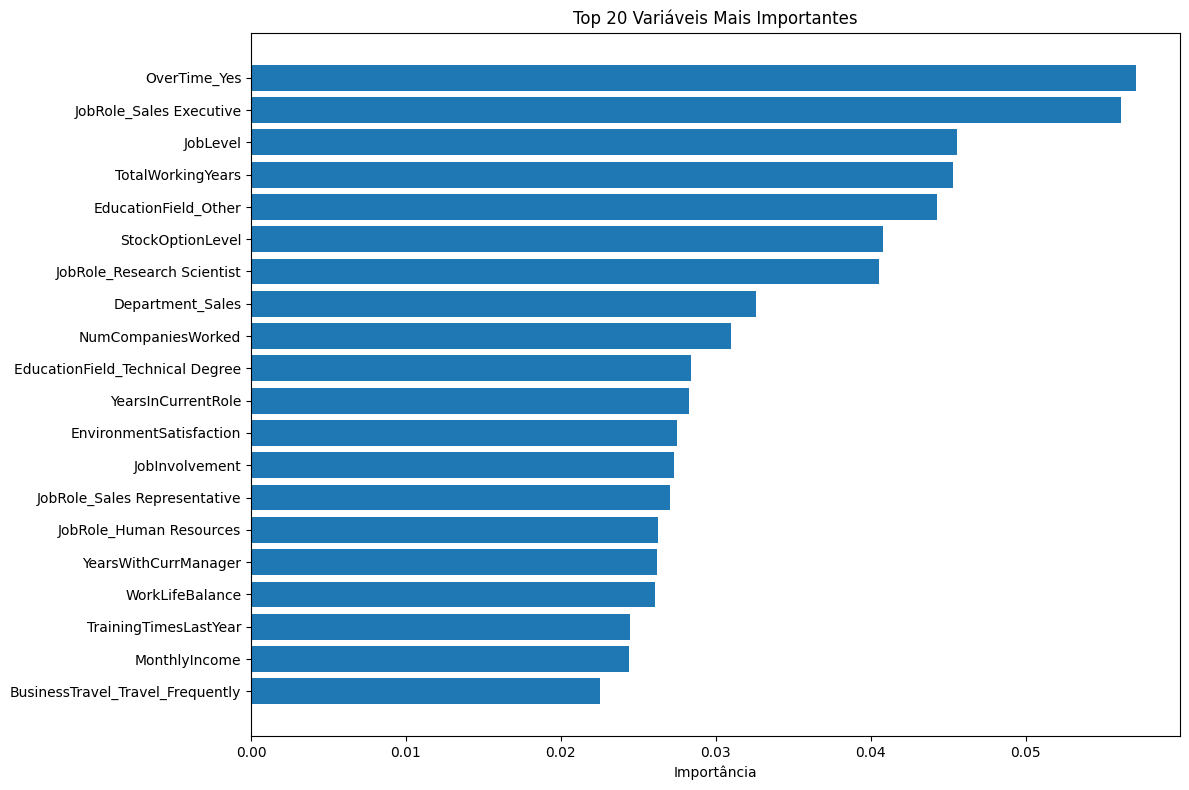

In [38]:
# Visualizar importância das variáveis

plt.figure(figsize=(12,8))

top20 = feature_importance.head(20)

plt.barh(
    top20["Variavel"],
    top20["Importancia"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Variáveis Mais Importantes")
plt.xlabel("Importância")
plt.tight_layout()

plt.show()

In [39]:
# Exportar importância das variáveis

feature_importance.to_excel(
    OUTPUT_DIR / "feature_importance.xlsx",
    index=False
)

In [40]:
# SHAP Global

import shap

In [41]:
explainer = shap.TreeExplainer(modelo)


In [42]:
# Calcular valores SHAP

shap_values = explainer.shap_values(
    X_test
)

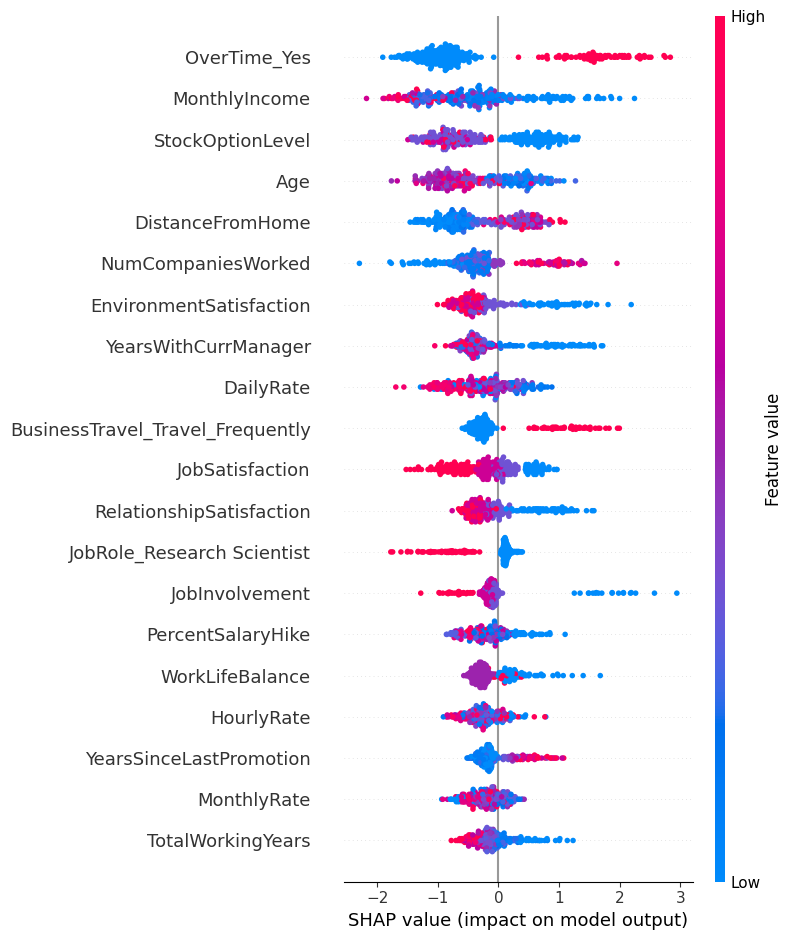

In [43]:
# Gráfico global

shap.summary_plot(
    shap_values,
    X_test
)

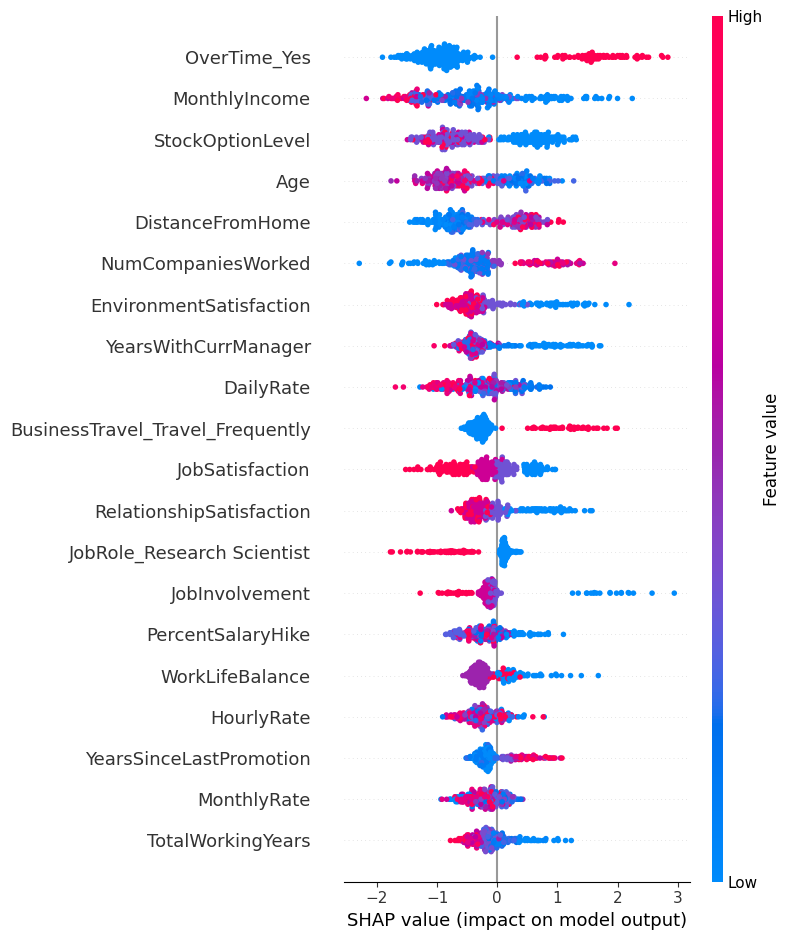

In [44]:
# Exportar gráfico global

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "shap_summary.png",
    bbox_inches="tight"
)

plt.show()

##### Conclusão – SHAP Global

A análise SHAP foi utilizada para compreender como as variáveis influenciam as previsões do modelo XGBoost.

Principais fatores associados ao aumento do risco de desligamento:

* Realização de horas extras (OverTime)
* Baixa remuneração mensal
* Baixo nível de Stock Options
* Menor idade
* Maior distância entre residência e trabalho
* Histórico de trabalho em várias empresas
* Viagens frequentes
* Baixa satisfação com o trabalho e ambiente organizacional

Principais fatores associados à retenção dos funcionários:

* Salários mais elevados
* Maior idade e experiência profissional
* Benefícios de Stock Options
* Maior satisfação no trabalho
* Melhor relacionamento com a liderança
* Maior equilíbrio entre vida pessoal e profissional

Os resultados confirmam os padrões identificados durante a análise exploratória e demonstram que fatores ligados à carga de trabalho, remuneração, satisfação e experiência profissional possuem papel central na previsão de turnover.


In [45]:
# SHAP Individual

probs = modelo.predict_proba(X_test)[:, 1]

predicoes = pd.DataFrame({
    "Probabilidade": probs
}, index=X_test.index)

predicoes.sort_values(
    by="Probabilidade",
    ascending=False
).head(10)

,Probabilidade
200,0.999850
92,0.999402
276,0.995345
81,0.991006
287,0.984719
214,0.983475
251,0.972965
223,0.959117
35,0.954896
199,0.948803


In [46]:
X_test.iloc[200]

Age                                    19
DailyRate                             419
DistanceFromHome                       21
Education                               3
EnvironmentSatisfaction                 4
HourlyRate                             37
JobInvolvement                          2
JobLevel                                1
JobSatisfaction                         2
MonthlyIncome                        2121
MonthlyRate                          9947
NumCompaniesWorked                      1
PercentSalaryHike                      13
PerformanceRating                       3
RelationshipSatisfaction                2
StockOptionLevel                        0
TotalWorkingYears                       1
TrainingTimesLastYear                   3
WorkLifeBalance                         4
YearsAtCompany                          1
YearsInCurrentRole                      0
YearsSinceLastPromotion                 0
YearsWithCurrManager                    0
BusinessTravel_Travel_Frequently  

In [47]:
X_test.iloc[92]

Age                                    25
DailyRate                             599
DistanceFromHome                       24
Education                               1
EnvironmentSatisfaction                 3
HourlyRate                             73
JobInvolvement                          1
JobLevel                                1
JobSatisfaction                         4
MonthlyIncome                        1118
MonthlyRate                          8040
NumCompaniesWorked                      1
PercentSalaryHike                      14
PerformanceRating                       3
RelationshipSatisfaction                4
StockOptionLevel                        0
TotalWorkingYears                       1
TrainingTimesLastYear                   4
WorkLifeBalance                         3
YearsAtCompany                          1
YearsInCurrentRole                      0
YearsSinceLastPromotion                 1
YearsWithCurrManager                    0
BusinessTravel_Travel_Frequently  

In [48]:
X_test.iloc[276]

Age                                     29
DailyRate                              906
DistanceFromHome                        10
Education                                3
EnvironmentSatisfaction                  4
HourlyRate                              92
JobInvolvement                           2
JobLevel                                 1
JobSatisfaction                          1
MonthlyIncome                         2404
MonthlyRate                          11479
NumCompaniesWorked                       6
PercentSalaryHike                       20
PerformanceRating                        4
RelationshipSatisfaction                 3
StockOptionLevel                         0
TotalWorkingYears                        3
TrainingTimesLastYear                    5
WorkLifeBalance                          3
YearsAtCompany                           0
YearsInCurrentRole                       0
YearsSinceLastPromotion                  0
YearsWithCurrManager                     0
BusinessTra

#### Conclusão Analítica - Sprint 6

A Sprint 6 teve como objetivo compreender os fatores que influenciam as previsões do modelo de turnover e tornar os resultados interpretáveis para tomada de decisão.

Na Task 6.1 foi realizada a análise de importância das variáveis utilizando o modelo XGBoost Balanceado. Os resultados mostraram que fatores como horas extras, cargo exercido, nível hierárquico, experiência profissional, benefícios corporativos e remuneração possuem forte influência na previsão de desligamento.

Na Task 6.2 foi aplicada a técnica SHAP Global para identificar não apenas a importância das variáveis, mas também a direção de seu impacto. A análise demonstrou que horas extras, salários baixos, ausência de stock options, menor idade, maior distância da residência, viagens frequentes e baixos níveis de satisfação estão associados ao aumento do risco de turnover.

Na Task 6.3 foram analisados casos individuais classificados como alto risco pelo modelo. As explicações confirmaram a coerência das previsões, evidenciando padrões como baixa remuneração, realização de horas extras, pouca experiência profissional, ausência de benefícios de retenção e baixa satisfação no trabalho.

Os resultados obtidos validam a capacidade do modelo em identificar fatores relevantes para o desligamento de funcionários e fornecem informações úteis para estratégias de retenção de talentos e gestão de pessoas.
